unpack and visualize convergence

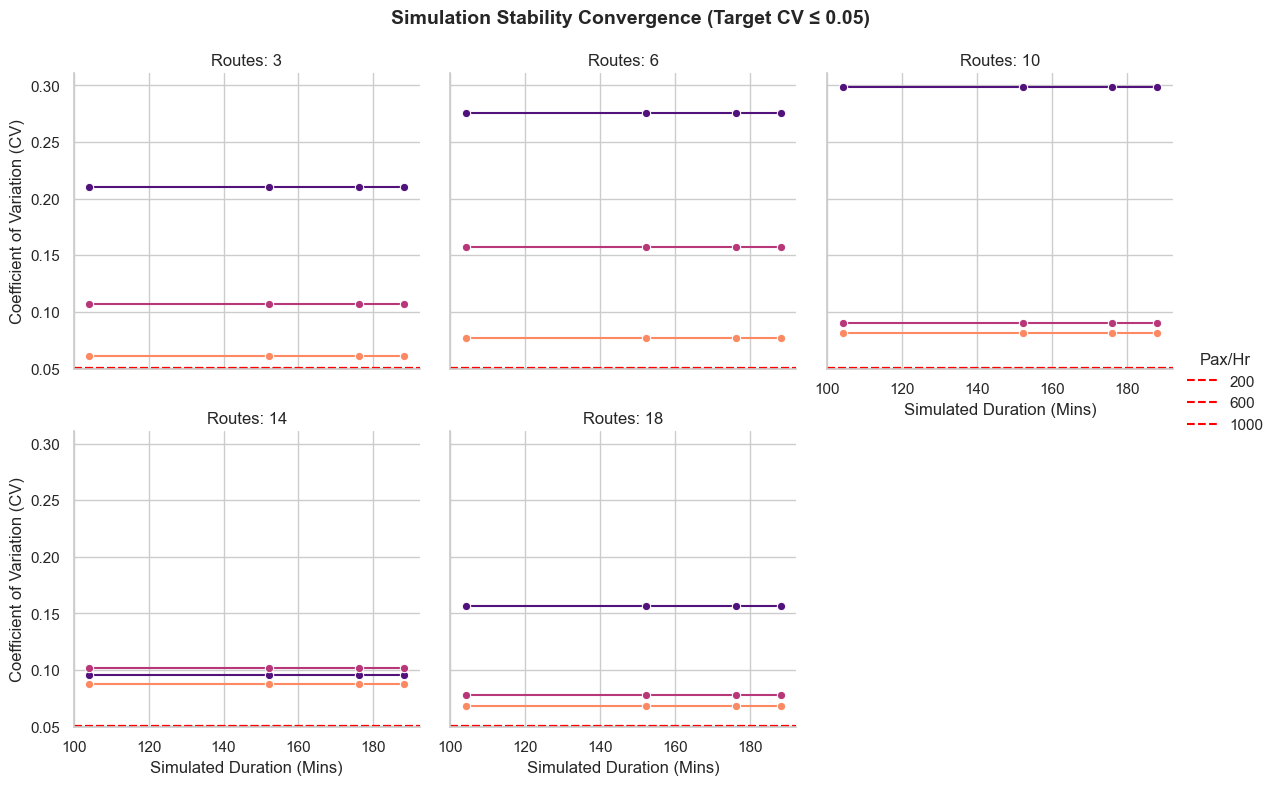

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import re

# 1. Load the results
df = pd.read_csv("rnd/csv/rnd1_stability_results.csv")

# 2. Unpack the 'ticks_log' column 
rows = []
for index, row in df.iterrows():
    raw_string = str(row['ticks_log'])
    
    # Strip out the 'np.float64(' and its closing ')' so ast can parse it safely
    clean_string = re.sub(r'np\.float64\((.*?)\)', r'\1', raw_string)
    
    # Convert the cleaned string back into a Python list of dictionaries
    ticks_log = ast.literal_eval(clean_string)
    
    for log in ticks_log:
        rows.append({
            'num_routes': row['num_routes'],
            'passenger_rate': row['passenger_rate'],
            'ticks': log['ticks'],
            'spt': row['optimal_spt'],
            # Calculate simulated duration in minutes
            'sim_duration_min': (log['ticks'] * row['optimal_spt']) / 60,
            'cv': log['cv']
        })

# Create a clean DataFrame from the unpacked logs
cv_df = pd.DataFrame(rows)

# 3. Visualize the CV Convergence Trend
sns.set_theme(style="whitegrid")
g = sns.FacetGrid(cv_df, col="num_routes", hue="passenger_rate", col_wrap=3, height=4, palette="magma")
g.map(sns.lineplot, "sim_duration_min", "cv", marker="o")

# Add the 5% threshold line to all subplots
g.map(plt.axhline, y=0.05, color="red", linestyle="--", label="5% Threshold")

# Formatting
g.set_axis_labels("Simulated Duration (Mins)", "Coefficient of Variation (CV)")
g.set_titles("Routes: {col_name}")
g.add_legend(title="Pax/Hr")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Simulation Stability Convergence (Target CV ≤ 0.05)", fontweight="bold", fontsize=14)

plt.show()